# Revisión de Literatura
## Clasificación de Desastres Naturales y Estimación de Pérdidas Económicas mediante Deep Learning

---

> **Proyecto:** Sistema Híbrido CNN + MLP para Clasificación de Imágenes Aéreas de Desastres y Estimación de Pérdidas Económicas  
> **Autor:** Luis Peñaranda  
> **Curso:** Deep Learning  

---

## 1. Introducción

Esta sección presenta la revisión de literatura que fundamenta la propuesta del pipeline híbrido **CNN → MLP**. Se analizan tres trabajos representativos del estado del arte en dos subproblemas complementarios:

1. **Clasificación de imágenes de desastres** mediante redes convolucionales ligeras.
2. **Estimación de pérdidas económicas post-desastre** mediante aprendizaje automático sobre datos históricos estructurados.

Ninguno de los trabajos revisados aborda ambos subproblemas de forma integrada en un sistema de extremo a extremo. Esta brecha motiva la arquitectura propuesta en el presente proyecto.

## 2. Tabla Comparativa de Literatura

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Datos de la tabla comparativa ──────────────────────────────────────────
data = {
    'Autor / Año': [
        'Yuan et al. (2025)\n[EFFC-Net]',
        'Chen & Zhang (2022)\n[AutoML Earthquake]',
        'Zhao et al. (2024)\n[Ensemble SVM+XGBoost]'
    ],
    'Problema': [
        'Clasificación multiclase de imágenes de desastres en teledetección (4 categorías)',
        'Predicción de tasa de víctimas y pérdidas económicas directas post-terremoto',
        'Estimación rápida de pérdidas económicas post-sismo (GDP relativo) en Sichuan, China, a nivel de distrito/condado'
    ],
    'Arquitectura': [
        'CNN ligera totalmente convolucional (EFFC-Net) con bloques EFFC_Block y EFFC_Tran_Block; depthwise conv, ReLU6, BN',
        'Framework AutoML (CASH) con SVM, kNN, RF, XGBoost, CatBoost, LightGBM; modelo de dos etapas (clasificador + regresor)',
        'Ensemble SVM (RBF) + XGBoost con stacking de segundo orden; Bayesian Optimization (UCB); SHAP para interpretabilidad; 30 features multi-fuente'
    ],
    'Dataset': [
        'Kaggle Cyclone-Wildfire-Flood-Earthquake (9 792 imágenes, 96 dpi); LIESMARS (Wuhan University)',
        '211 terremotos destructivos en China continental (2001–2019); EM-DAT, China Statistical Yearbook, USGS ShakeMap',
        'Sismos ≥M5 en Sichuan 2007–2021 (14 eventos, 180 unidades administrativas); Sichuan Statistical Yearbook; USGS; GB 18306-2015'
    ],
    'Métricas Clave': [
        'Precisión: 0.904 | Recall: 0.932 | F1: 0.917 | Params: 0.05 M | AUC: 0.990',
        'MAE (víctimas): 0.000077 | R2: 0.657 | MAE (perd. econ.): 0.0247 | R2: 0.633',
        "R2=0.931 (val) | SMAPE=0.541 | Theils U=0.262 (ensemble); SVM solo: R2=0.912; XGBoost solo: R2=0.832"
    ],
    'Limitaciones': [
        '(1) No estima pérdidas económicas. (2) Dataset pequeño por categoría (ej. ciclones: 929 imágenes). (3) Sin integración con datos históricos de pérdidas.',
        '(1) Solo terremotos; no generaliza a otros tipos de desastre. (2) Requiere indicadores socioeconómicos previos (no inferibles de imágenes). (3) No usa imágenes satelitales.',
        '(1) Solo sismos en Sichuan, China; no generaliza a otros desastres. (2) No usa imágenes; requiere datos sísmicos y socioeconómicos estructurados. (3) Estimación puntual sin rango probabilístico. (4) Muestra pequeña de eventos de alta magnitud.'
    ]
}

df = pd.DataFrame(data)

# ── Estilos de visualización ───────────────────────────────────────────────
from IPython.display import HTML

html_table = df.style\
    .set_table_styles([
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'),
                   ('width', '100%'),
                   ('background-color', '#ffffff'),
                   ('color', '#212529'),
                   ('font-family', 'Arial, sans-serif')]},
        {'selector': 'thead th',
         'props': [('background-color', '#2c3e50'),
                   ('color', '#ffffff'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center'),
                   ('padding', '10px 12px'),
                   ('font-size', '13px'),
                   ('border', '1px solid #2c3e50')]},
        {'selector': 'tbody td',
         'props': [('background-color', '#ffffff'),
                   ('color', '#212529'),
                   ('padding', '10px 14px'),
                   ('vertical-align', 'top'),
                   ('font-size', '12px'),
                   ('border-bottom', '1px solid #dee2e6'),
                   ('line-height', '1.5')]},
        {'selector': 'tbody tr:nth-child(odd) td',
         'props': [('background-color', '#f8f9fa'),
                   ('color', '#212529')]},
        {'selector': 'tbody tr:nth-child(even) td',
         'props': [('background-color', '#ffffff'),
                   ('color', '#212529')]},
        {'selector': 'tbody tr:first-child td',
         'props': [('border-left', '5px solid #e74c3c')]},
        {'selector': 'tbody tr:nth-child(2) td',
         'props': [('border-left', '5px solid #3498db')]},
        {'selector': 'tbody tr:nth-child(3) td',
         'props': [('border-left', '5px solid #2ecc71')]},
        {'selector': 'tbody tr:hover td',
         'props': [('background-color', '#e8f4f8 !important'),
                   ('color', '#212529 !important')]},
    ])\
    .set_properties(**{
        'white-space': 'pre-wrap',
        'word-wrap': 'break-word',
        'background-color': '#ffffff',
        'color': '#212529'
    })\
    .hide(axis='index')

# Wrap in a div with explicit light background to override Jupyter dark theme
raw_html = html_table.to_html()
wrapped = f'''<div style="background-color:#ffffff; color:#212529; padding:16px; border-radius:8px; box-shadow:0 2px 8px rgba(0,0,0,0.12);">
<style>
  .lit-table table {{ background-color: #ffffff !important; color: #212529 !important; }}
  .lit-table td, .lit-table th {{ background-color: inherit !important; color: #212529 !important; }}
  .lit-table tbody tr:nth-child(odd) td {{ background-color: #f8f9fa !important; color: #212529 !important; }}
  .lit-table tbody tr:nth-child(even) td {{ background-color: #ffffff !important; color: #212529 !important; }}
  .lit-table tbody tr:first-child td {{ border-left: 5px solid #e74c3c !important; }}
  .lit-table tbody tr:nth-child(2) td {{ border-left: 5px solid #3498db !important; }}
  .lit-table tbody tr:nth-child(3) td {{ border-left: 5px solid #2ecc71 !important; }}
</style>
<div class="lit-table">{raw_html}</div>
</div>'''

HTML(wrapped)

Autor / Año,Problema,Arquitectura,Dataset,Métricas Clave,Limitaciones
Yuan et al. (2025) [EFFC-Net],Clasificación multiclase de imágenes de desastres en teledetección (4 categorías),"CNN ligera totalmente convolucional (EFFC-Net) con bloques EFFC_Block y EFFC_Tran_Block; depthwise conv, ReLU6, BN","Kaggle Cyclone-Wildfire-Flood-Earthquake (9 792 imágenes, 96 dpi); LIESMARS (Wuhan University)",Precisión: 0.904 | Recall: 0.932 | F1: 0.917 | Params: 0.05 M | AUC: 0.990,(1) No estima pérdidas económicas. (2) Dataset pequeño por categoría (ej. ciclones: 929 imágenes). (3) Sin integración con datos históricos de pérdidas.
Chen & Zhang (2022) [AutoML Earthquake],Predicción de tasa de víctimas y pérdidas económicas directas post-terremoto,"Framework AutoML (CASH) con SVM, kNN, RF, XGBoost, CatBoost, LightGBM; modelo de dos etapas (clasificador + regresor)","211 terremotos destructivos en China continental (2001–2019); EM-DAT, China Statistical Yearbook, USGS ShakeMap",MAE (víctimas): 0.000077 | R2: 0.657 | MAE (perd. econ.): 0.0247 | R2: 0.633,(1) Solo terremotos; no generaliza a otros tipos de desastre. (2) Requiere indicadores socioeconómicos previos (no inferibles de imágenes). (3) No usa imágenes satelitales.
Zhao et al. (2024) [Ensemble SVM+XGBoost],"Estimación rápida de pérdidas económicas post-sismo (GDP relativo) en Sichuan, China, a nivel de distrito/condado",Ensemble SVM (RBF) + XGBoost con stacking de segundo orden; Bayesian Optimization (UCB); SHAP para interpretabilidad; 30 features multi-fuente,"Sismos ≥M5 en Sichuan 2007–2021 (14 eventos, 180 unidades administrativas); Sichuan Statistical Yearbook; USGS; GB 18306-2015",R2=0.931 (val) | SMAPE=0.541 | Theils U=0.262 (ensemble); SVM solo: R2=0.912; XGBoost solo: R2=0.832,"(1) Solo sismos en Sichuan, China; no generaliza a otros desastres. (2) No usa imágenes; requiere datos sísmicos y socioeconómicos estructurados. (3) Estimación puntual sin rango probabilístico. (4) Muestra pequeña de eventos de alta magnitud."


## 3. Gap Identificado y Motivación de la Propuesta

---

###  ¿Qué no hace ninguno de los tres trabajos?

El análisis comparativo revela una **brecha estructural** en la literatura revisada: ninguno de los tres trabajos integra la percepción visual del desastre (imagen satelital o aérea) con la estimación probabilística de sus consecuencias económicas en un único pipeline de inferencia.

| Capacidad | EFFC-Net (2025) | Chen & Zhang (2022) | Zhao et al. (2024) | **Este proyecto** |
|---|:---:|:---:|:---:|:---:|
| Clasificación de tipo de desastre desde imagen | ✅ | ❌ | ❌ | ✅ |
| Estimación de pérdidas económicas | ❌ | ✅ (solo sismos) | ✅ (solo sismos) | ✅ (4 tipos) |
| Pipeline imagen → pérdidas integrado | ❌ | ❌ | ❌ | ✅ |
| Salida como rango probabilístico | ❌ | ❌ | ❌ | ✅ |
| Multi-tipo de desastre | ✅ | ❌ | ❌ | ✅ |
| Datos históricos EM-DAT como supervisión | ❌ | Parcial | Parcial | ✅ |

---

###  ¿Qué resuelve la propuesta de este proyecto?

La propuesta aborda tres brechas concretas:

**1. Desconexión entre percepción visual y estimación económica.**  
Los modelos de clasificación visual (Yuan et al., 2025) producen una etiqueta de categoría, pero no ofrecen ningún mecanismo para traducir ese resultado en consecuencias operacionalmente útiles para entidades como aseguradoras o agencias de gestión del riesgo (ej. UNGRD Colombia). Los modelos de estimación de pérdidas (Chen & Zhang, 2022; Zhao et al., 2024) requieren indicadores sísmicos y socioeconómicos que no se derivan de imágenes.

**2. Restricción a un único tipo de desastre.**  
Chen & Zhang (2022) y Zhao et al. (2024) están diseñados exclusivamente para sismos. La presente propuesta generaliza la estimación de pérdidas a cuatro tipos de desastre (inundación, terremoto, incendio, ciclón) mediante una MLP que recibe la clase predicha como entrada categórica junto con covariables históricas de EM-DAT.

**3. Ausencia de salida probabilística.**  
Los modelos de referencia producen estimaciones puntuales. Este proyecto introduce un **rango probabilístico de pérdidas económicas** (cuantiles Q10–Q90), más adecuado para la toma de decisiones bajo incertidumbre en contextos de alerta temprana.

> **Conclusión del gap:** Existe la necesidad de un sistema que, a partir de una imagen de desastre, infiera automáticamente el tipo de evento y genere un rango estimado de pérdidas económicas históricamente fundamentado. Ese es el objetivo central de este proyecto.

## 4. Revisión de Literatura (Párrafo Académico — Formato APA)

La clasificación automática de imágenes de desastres naturales y la estimación de sus consecuencias económicas constituyen dos líneas de investigación que, hasta la fecha, han avanzado de manera independiente en la literatura de aprendizaje profundo.

**Yuan et al. (2025)** propusieron EFFC-Net, una CNN ligera y totalmente convolucional para clasificar imágenes de teledetección en cuatro categorías de desastre (terremoto, inundación, incendio, ciclón). Con bloques modulares basados en convoluciones *depthwise* agrupadas, normalización por lotes y ReLU6, el modelo alcanza un F1-score de 0.917 y AUC de 0.990 con apenas 0.05 M de parámetros, superando arquitecturas CNN y transformadores de mayor escala. Sin embargo, EFFC-Net no incorpora ningún mecanismo de estimación del impacto económico derivado de la clasificación producida.

**Chen y Zhang (2022)** presentaron un framework AutoML para predecir la tasa de víctimas y pérdidas económicas directas post-terremoto en China continental. El sistema combina selección automática de algoritmos (CASH) con un modelo de dos etapas —clasificador de eventos con cero víctimas seguido de un regresor— entrenado sobre indicadores sísmicos, demográficos y socioeconómicos del *China Statistical Yearbook*, logrando MAE de 0.000077 y R² de 0.657 para la tasa de víctimas.

**Zhao et al. (2024)** desarrollaron un ensemble interpretable de SVM (kernel RBF) y XGBoost con stacking de segundo orden para cuantificar rápidamente pérdidas económicas relativas al PIB por sismos en Sichuan, China. El modelo emplea 30 variables multi-fuente (peligrosidad sísmica, exposición socioeconómica, vulnerabilidad constructiva), optimización bayesiana de hiperparámetros y valores SHAP para la interpretabilidad, alcanzando R² de 0.931 y Theil's U de 0.262 en validación.

Los tres trabajos revelan una **brecha metodológica común**: ninguno integra la percepción visual del desastre con la estimación probabilística de pérdidas económicas en un pipeline de extremo a extremo. La presente propuesta cierra esa brecha mediante una arquitectura híbrida CNN + MLP, donde la red convolucional actúa como disparador de clasificación y la MLP genera un rango probabilístico de pérdidas (Q10–Q90) a partir de datos históricos de EM-DAT.

---

**Referencias**

Chen, W., & Zhang, L. (2022). An automated machine learning approach for earthquake casualty rate and economic loss prediction. *Reliability Engineering and System Safety, 225*, 108645. https://doi.org/10.1016/j.ress.2022.108645

Yuan, J., Ma, X., Zhang, Z., Xu, Q., Han, G., Li, S., Gong, W., Liu, F., & Cai, X. (2025). EFFC-Net: lightweight fully convolutional neural networks in remote sensing disaster images. *Geo-spatial Information Science, 28*(1), 212–223. https://doi.org/10.1080/10095020.2023.2183145

Zhao, J., Li, X., Chen, S., & Liu, C. (2024). Multi-source driven estimation of earthquake economic losses: A comprehensive and interpretable ensemble machine learning model. *International Journal of Disaster Risk Reduction, 106*, 104377. https://doi.org/10.1016/j.ijdrr.2024.104377

## 5. Diagrama del Pipeline Híbrido Propuesto

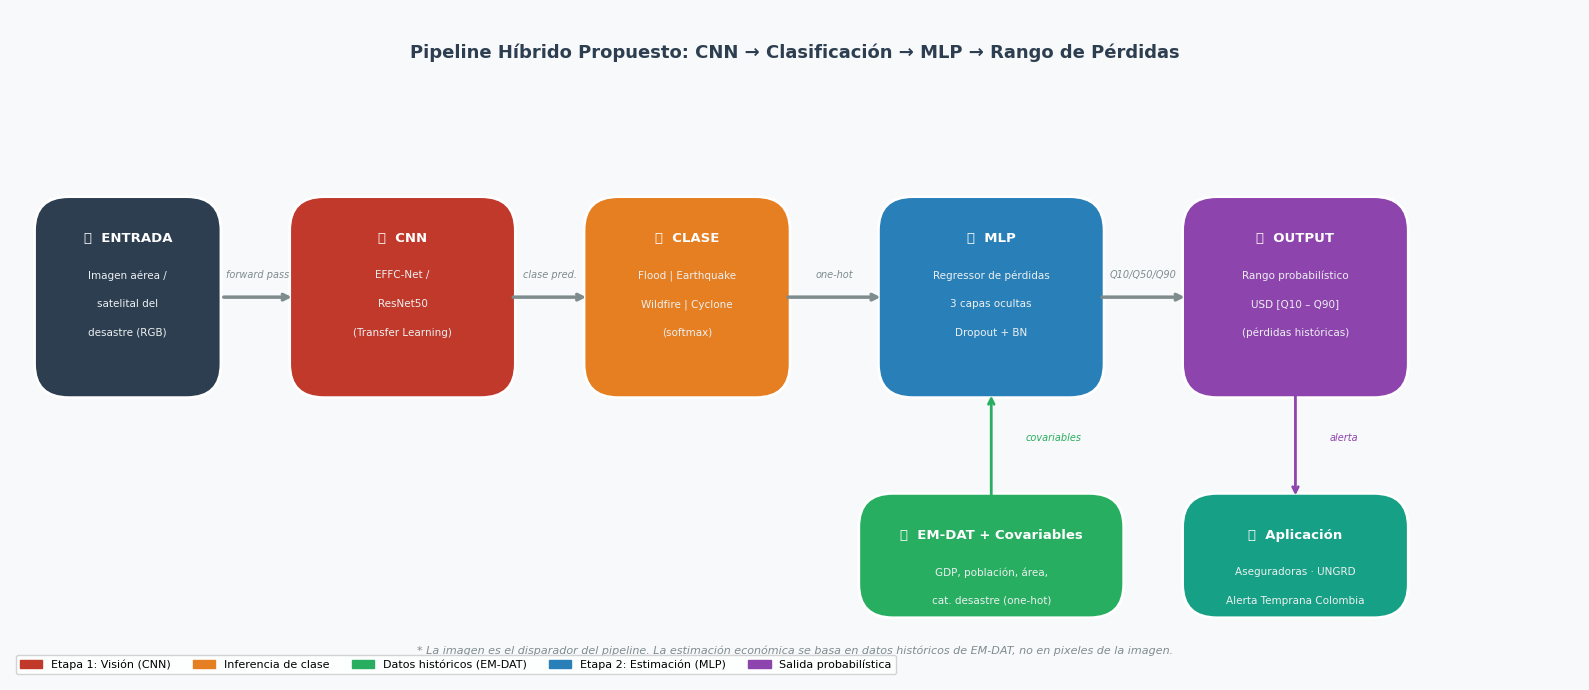

✅ Diagrama guardado como pipeline_diagram.png


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe
import numpy as np

fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(0, 16)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

# ── Paleta de colores ──────────────────────────────────────────────────────
C_INPUT   = '#2c3e50'
C_CNN     = '#c0392b'
C_CLASS   = '#e67e22'
C_EMDAT   = '#27ae60'
C_MLP     = '#2980b9'
C_OUTPUT  = '#8e44ad'
C_APP     = '#16a085'
C_ARROW   = '#7f8c8d'
C_TEXT    = 'white'

def draw_box(ax, x, y, w, h, color, title, subtitle_lines, radius=0.35):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle=f'round,pad=0.05,rounding_size={radius}',
                          linewidth=2, edgecolor='white',
                          facecolor=color, zorder=3)
    ax.add_patch(box)
    ax.text(x, y + h/2 - 0.32, title,
            ha='center', va='top', fontsize=9.5,
            fontweight='bold', color=C_TEXT, zorder=4)
    for i, line in enumerate(subtitle_lines):
        ax.text(x, y + h/2 - 0.72 - i*0.30, line,
                ha='center', va='top', fontsize=7.5,
                color='#ecf0f1', zorder=4)

def draw_arrow(ax, x1, y, x2, label='', color=C_ARROW):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=2.5, connectionstyle='arc3,rad=0'))
    if label:
        ax.text((x1+x2)/2, y + 0.18, label,
                ha='center', va='bottom', fontsize=7,
                color=color, style='italic')

# ── Fila principal del pipeline (y = 4.0) ─────────────────────────────────
Y_MAIN = 4.0
BOX_H  = 2.0

# INPUT
draw_box(ax, 1.2, Y_MAIN, 1.8, BOX_H, C_INPUT,
         '🛰  ENTRADA',
         ['Imagen aérea /','satelital del','desastre (RGB)'])

# CNN
draw_box(ax, 4.0, Y_MAIN, 2.2, BOX_H, C_CNN,
         '🔴  CNN',
         ['EFFC-Net /','ResNet50','(Transfer Learning)'])

# CLASIFICACIÓN
draw_box(ax, 6.9, Y_MAIN, 2.0, BOX_H, C_CLASS,
         '🏷  CLASE',
         ['Flood | Earthquake','Wildfire | Cyclone','(softmax)'])

# MLP
draw_box(ax, 10.0, Y_MAIN, 2.2, BOX_H, C_MLP,
         '🔵  MLP',
         ['Regressor de pérdidas','3 capas ocultas','Dropout + BN'])

# OUTPUT
draw_box(ax, 13.1, Y_MAIN, 2.2, BOX_H, C_OUTPUT,
         '📊  OUTPUT',
         ['Rango probabilístico','USD [Q10 – Q90]','(pérdidas históricas)'])

# ── EM-DAT (caja auxiliar abajo) ───────────────────────────────────────────
draw_box(ax, 10.0, 1.3, 2.6, 1.2, C_EMDAT,
         '🗃  EM-DAT + Covariables',
         ['GDP, población, área,','cat. desastre (one-hot)'])

# ── Aplicación (caja abajo a la derecha) ───────────────────────────────────
draw_box(ax, 13.1, 1.3, 2.2, 1.2, C_APP,
         '🏢  Aplicación',
         ['Aseguradoras · UNGRD','Alerta Temprana Colombia'])

# ── Flechas horizontales principales ──────────────────────────────────────
draw_arrow(ax, 2.15, Y_MAIN, 2.9,  'forward pass')
draw_arrow(ax, 5.1,  Y_MAIN, 5.9,  'clase pred.')
draw_arrow(ax, 7.9,  Y_MAIN, 8.9,  'one-hot')
draw_arrow(ax, 11.1, Y_MAIN, 12.0, 'Q10/Q50/Q90')

# Flecha EM-DAT → MLP (vertical)
ax.annotate('', xy=(10.0, Y_MAIN - BOX_H/2),
            xytext=(10.0, 1.3 + 0.6),
            arrowprops=dict(arrowstyle='->', color=C_EMDAT, lw=2))
ax.text(10.35, 2.5, 'covariables', fontsize=7, color=C_EMDAT, style='italic')

# Flecha OUTPUT → Aplicación (vertical)
ax.annotate('', xy=(13.1, 1.3 + 0.6),
            xytext=(13.1, Y_MAIN - BOX_H/2),
            arrowprops=dict(arrowstyle='->', color=C_OUTPUT, lw=2))
ax.text(13.45, 2.5, 'alerta', fontsize=7, color=C_OUTPUT, style='italic')

# ── Títulos y notas ────────────────────────────────────────────────────────
ax.text(8.0, 6.65, 'Pipeline Híbrido Propuesto: CNN → Clasificación → MLP → Rango de Pérdidas',
        ha='center', va='top', fontsize=13, fontweight='bold', color='#2c3e50')

ax.text(8.0, 0.25,
        '* La imagen es el disparador del pipeline. La estimación económica se basa en datos históricos de EM-DAT, no en pixeles de la imagen.',
        ha='center', va='bottom', fontsize=8, color='#7f8c8d', style='italic')

# Leyenda de colores
legend_patches = [
    mpatches.Patch(color=C_CNN,   label='Etapa 1: Visión (CNN)'),
    mpatches.Patch(color=C_CLASS, label='Inferencia de clase'),
    mpatches.Patch(color=C_EMDAT, label='Datos históricos (EM-DAT)'),
    mpatches.Patch(color=C_MLP,   label='Etapa 2: Estimación (MLP)'),
    mpatches.Patch(color=C_OUTPUT,label='Salida probabilística'),
]
ax.legend(handles=legend_patches, loc='lower left',
          fontsize=8, framealpha=0.85, ncol=5,
          bbox_to_anchor=(0, 0.0))

plt.tight_layout()
plt.savefig('pipeline_diagram.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Diagrama guardado como pipeline_diagram.png')

### 5.1 Descripción Textual del Pipeline (ASCII)

```
┌─────────────────────────────────────────────────────────────────────────────────────┐
│                        PIPELINE HÍBRIDO — VISTA GENERAL                            │
└─────────────────────────────────────────────────────────────────────────────────────┘

  🛰 IMAGEN AÉREA/SATELITAL
        │
        ▼  (forward pass)
  ┌─────────────┐
  │   CNN       │  ← EFFC-Net / ResNet50 (Transfer Learning)
  │  (Etapa 1)  │    Entrenada en: Kaggle Disaster Dataset
  │             │    Salida: logits sobre 4 clases
  └─────┬───────┘
        │  softmax → argmax
        ▼
  ┌─────────────────────────────────────────────┐
  │  CLASE PREDICHA (one-hot encoding)          │
  │  [Flood | Earthquake | Wildfire | Cyclone]  │
  └──────────────────┬──────────────────────────┘
                     │
                     │  concat con covariables EM-DAT
                     │  (GDP, población, área afectada, año)
                     ▼
  ┌─────────────┐         ┌──────────────────────────────┐
  │   MLP       │ ◄───────┤  EM-DAT (datos históricos)   │
  │  (Etapa 2)  │         │  ~5 000 eventos globales      │
  │  3 capas    │         │  1990 – 2023                  │
  │  Dropout    │         └──────────────────────────────┘
  │  + BN       │
  └──────┬──────┘
         │  regresión cuantílica (Q10, Q50, Q90)
         ▼
  ┌─────────────────────────────────┐
  │  RANGO DE PÉRDIDAS ECONÓMICAS   │
  │  USD [mínimo estimado – máximo  │
  │       estimado] con P80         │
  └────────────┬────────────────────┘
               │
               ▼
  APLICACIÓN: Aseguradoras / UNGRD / Gestión del Riesgo
```

> **Nota conceptual clave:** La imagen actúa como **disparador** del pipeline. No se extraen características económicas de los píxeles; la CNN solo determina *qué tipo* de desastre ocurrió. La estimación económica proviene del modelo MLP entrenado sobre el histórico de EM-DAT, condicionado a la clase de desastre predicha y a covariables del contexto geográfico.

## 6. Especificación Técnica del Pipeline

In [6]:
import pandas as pd
from IPython.display import HTML

spec_data = {
    'Componente': [
        'Etapa 1: CNN (Clasificación)',
        'Etapa 1: CNN (Clasificación)',
        'Etapa 1: CNN (Clasificación)',
        'Etapa 1: CNN (Clasificación)',
        'Etapa 1: CNN (Clasificación)',
        'Interfaz 1→2',
        'Interfaz 1→2',
        'Etapa 2: MLP (Estimación)',
        'Etapa 2: MLP (Estimación)',
        'Etapa 2: MLP (Estimación)',
        'Etapa 2: MLP (Estimación)',
        'Etapa 2: MLP (Estimación)',
        'Salida'
    ],
    'Parámetro': [
        'Arquitectura base',
        'Dataset de entrenamiento',
        'Clases de salida',
        'Función de pérdida',
        'Métricas de evaluación',
        'Representación de clase',
        'Covariables EM-DAT',
        'Arquitectura',
        'Dataset de entrenamiento',
        'Variable objetivo',
        'Tipo de salida',
        'Función de pérdida',
        'Formato final'
    ],
    'Valor / Descripción': [
        'EFFC-Net (Yuan et al., 2025) o ResNet50 con Transfer Learning',
        'Kaggle Disaster Dataset — 9 792 imágenes (4 clases)',
        'Flood, Earthquake, Wildfire, Cyclone',
        'Cross-Entropy Loss + SGD',
        'F1-score macro, Precisión, Recall, AUC-ROC',
        'One-hot encoding (dim=4) + concatenación con covariables',
        'GDP del área afectada, población expuesta, área geográfica, año del evento',
        'MLP — 3 capas ocultas [256, 128, 64] + Dropout(0.3) + BatchNorm',
        'EM-DAT global (~5 000 eventos, 1990–2023) — pérdidas económicas directas',
        'Pérdida económica directa (USD) — log-transformada para normalizar distribución',
        'Regresión cuantílica: Q10, Q50, Q90',
        'Pinball Loss (quantile regression)',
        'Rango probabilístico USD [Q10 – Q90] con mediana (Q50)'
    ]
}

df_spec = pd.DataFrame(spec_data)

# Colores más saturados por componente
component_colors = {
    'Etapa 1: CNN (Clasificación)': '#f8c9c5',  # rojo más vivo
    'Interfaz 1→2':                 '#ffd9a0',  # naranja más vivo
    'Etapa 2: MLP (Estimación)':    '#b3d9f7',  # azul más vivo
    'Salida':                       '#d4b8f0'   # morado más vivo
}

def color_rows(row):
    bg = component_colors.get(row['Componente'], '#ffffff')
    return [f'background-color: {bg} !important; color: #1a1a1a !important;'] * len(row)

styled_spec = (
    df_spec.style
    .apply(color_rows, axis=1)
    .set_table_styles([
        {'selector': 'table',
         'props': [('background-color', '#ffffff'),
                   ('color', '#1a1a1a'),
                   ('font-family', 'Arial, sans-serif'),
                   ('border-collapse', 'collapse'),
                   ('width', '100%')]},
        {'selector': 'thead th',
         'props': [('background-color', '#2c3e50 !important'),
                   ('color', '#ffffff !important'),
                   ('font-weight', 'bold'),
                   ('padding', '11px 14px'),
                   ('font-size', '12px'),
                   ('text-align', 'left'),
                   ('letter-spacing', '0.3px')]},
        {'selector': 'tbody td',
         'props': [('padding', '8px 12px'),
                   ('font-size', '11.5px'),
                   ('border-bottom', '1px solid #c8c8c8'),
                   ('color', '#1a1a1a !important'),
                   ('line-height', '1.5')]},
    ])
    .hide(axis='index')
)

raw_html = styled_spec.to_html()
wrapped = f'''<div style="background-color:#ffffff; color:#1a1a1a; padding:16px;
                          border-radius:8px; box-shadow:0 2px 10px rgba(0,0,0,0.15);">
<style>
  .spec-table table {{ background-color: #ffffff !important; color: #1a1a1a !important; }}
  .spec-table td, .spec-table th {{ color: #1a1a1a !important; }}
</style>
<div class="spec-table">{raw_html}</div>
</div>'''

HTML(wrapped)

Componente,Parámetro,Valor / Descripción
Etapa 1: CNN (Clasificación),Arquitectura base,"EFFC-Net (Yuan et al., 2025) o ResNet50 con Transfer Learning"
Etapa 1: CNN (Clasificación),Dataset de entrenamiento,Kaggle Disaster Dataset — 9 792 imágenes (4 clases)
Etapa 1: CNN (Clasificación),Clases de salida,"Flood, Earthquake, Wildfire, Cyclone"
Etapa 1: CNN (Clasificación),Función de pérdida,Cross-Entropy Loss + SGD
Etapa 1: CNN (Clasificación),Métricas de evaluación,"F1-score macro, Precisión, Recall, AUC-ROC"
Interfaz 1→2,Representación de clase,One-hot encoding (dim=4) + concatenación con covariables
Interfaz 1→2,Covariables EM-DAT,"GDP del área afectada, población expuesta, área geográfica, año del evento"
Etapa 2: MLP (Estimación),Arquitectura,"MLP — 3 capas ocultas [256, 128, 64] + Dropout(0.3) + BatchNorm"
Etapa 2: MLP (Estimación),Dataset de entrenamiento,"EM-DAT global (~5 000 eventos, 1990–2023) — pérdidas económicas directas"
Etapa 2: MLP (Estimación),Variable objetivo,Pérdida económica directa (USD) — log-transformada para normalizar distribución


## 7. Limitaciones y Alcance del Modelo

---

### 7.1 Rol de la Imagen en el Pipeline

Es fundamental comprender que **la imagen satelital o aérea es el disparador del pipeline, no la fuente de la estimación económica**. La CNN procesa la imagen y produce una clasificación del tipo de desastre; esa clasificación actúa como variable categórica de entrada para la MLP. El modelo MLP estima las pérdidas económicas a partir de datos históricos de EM-DAT condicionados a esa categoría, no a partir de características visuales del daño en la imagen.

Esta distinción tiene implicaciones prácticas importantes:
- La CNN no requiere imágenes de post-impacto de alta resolución para inferir daños; solo necesita clasificar correctamente el tipo de evento.
- La MLP puede operar con covariables disponibles en tiempo real (GDP regional, densidad poblacional del área afectada) sin necesidad de inspección visual detallada.
- El sistema puede activarse en las primeras horas post-evento, cuando las imágenes de daño estructural aún no están disponibles.

---

### 7.2 Naturaleza Probabilística de la Salida

El output del sistema es un **rango probabilístico de pérdidas económicas**, no un valor puntual. Se produce mediante regresión cuantílica sobre tres cuantiles:

| Cuantil | Interpretación |
|:---:|---|
| **Q10** | Escenario optimista: el 10% de eventos históricos similares generó pérdidas menores a este valor |
| **Q50** | Mediana histórica: estimación central más probable |
| **Q90** | Escenario adverso: el 90% de eventos históricos similares generó pérdidas menores a este valor |

Este formato es más adecuado para la toma de decisiones en contextos de gestión del riesgo que una estimación puntual, ya que comunica explícitamente la incertidumbre del modelo.

---

### 7.3 Limitaciones Explícitas

**Limitaciones del componente CNN:**
- El dataset de entrenamiento contiene desbalance de clases (Flood: 3 810 imágenes vs. Cyclone: 929 imágenes), lo que puede sesgar el clasificador hacia las clases mayoritarias.
- Las imágenes de entrenamiento son de resolución estándar (96 dpi); el rendimiento puede degradarse con imágenes de muy alta o muy baja resolución.
- La red clasifica el *tipo* de desastre, no la *severidad* visual ni el área de daño.

**Limitaciones del componente MLP:**
- EM-DAT reporta pérdidas a nivel de país, no de región específica; la granularidad espacial es limitada.
- Los registros históricos de pérdidas económicas son heterogéneos en su metodología de reporte entre países y décadas.
- La distribución de pérdidas en EM-DAT está sesgada hacia eventos de gran magnitud; los eventos menores pueden estar subrepresentados.
- El modelo no captura efectos de correlación espacial entre desastres simultáneos.

**Limitaciones del sistema integrado:**
- El pipeline supone que el tipo de desastre es identificable desde la imagen; errores de clasificación en la CNN se propagan a la estimación de pérdidas.
- No incorpora datos en tiempo real de instrumentos sísmicos, meteorológicos ni de caudales hidrológicos.
- El alcance geográfico de validación es global (EM-DAT); la calibración para Colombia (UNGRD) requeriría fine-tuning con datos locales de la base de datos DESINVENTAR.

---

### 7.4 Alcance y Aplicabilidad

El sistema propuesto está diseñado como **herramienta de apoyo a la decisión en la fase de alerta temprana** (primeras 0–6 horas post-evento), no como reemplazo de evaluaciones de daño detalladas. Sus usuarios objetivo son:

- **Entidades de gestión del riesgo** (UNGRD Colombia, CEPREDENAC): orientación rápida de recursos de respuesta.
- **Sector asegurador**: estimación preliminar de exposición de cartera ante eventos catastróficos.
- **Investigadores**: benchmark de línea base para sistemas más complejos de evaluación post-desastre.



## 8. Visualización: Cobertura de los Papers por Dimensión del Problema

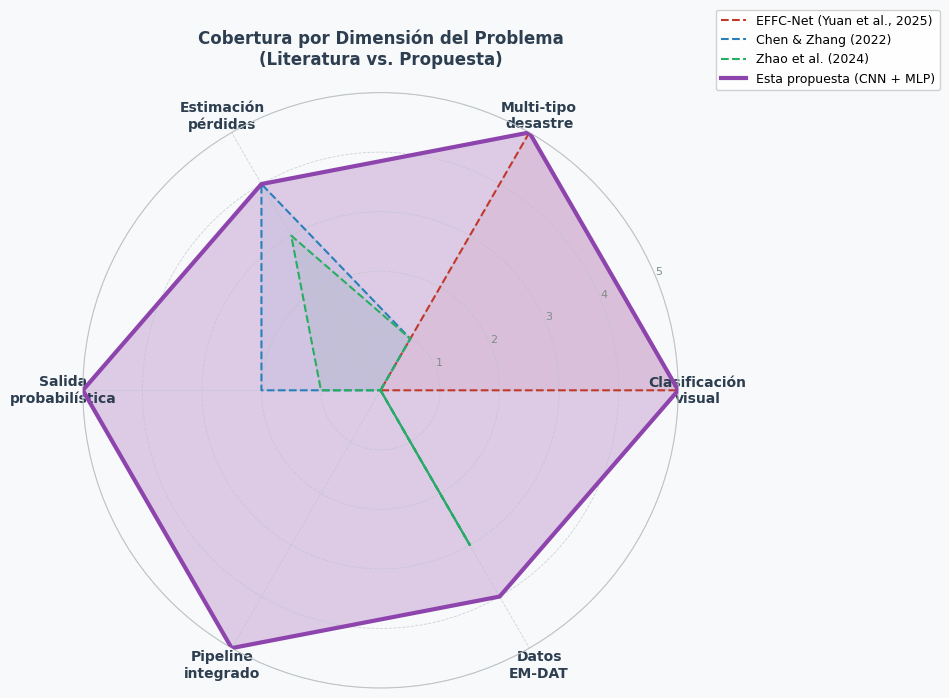

✅ Radar chart guardado como radar_coverage.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

# ── Radar Chart — Cobertura por dimensión ─────────────────────────────────
dimensiones = [
    'Clasificación\nvisual',
    'Multi-tipo\ndesastre',
    'Estimación\npérdidas',
    'Salida\nprobabilística',
    'Pipeline\nintegrado',
    'Datos\nEM-DAT'
]

# Scores (0-5) para cada paper y para la propuesta
scores = {
    'EFFC-Net (Yuan et al., 2025)':    [5, 5, 0, 0, 0, 0],
    'Chen & Zhang (2022)':             [0, 1, 4, 2, 0, 3],
    'Zhao et al. (2024)':              [0, 1, 3, 1, 0, 3],
    'Esta propuesta (CNN + MLP)':      [5, 5, 4, 5, 5, 4],
}

colors = ['#c0392b', '#2980b9', '#27ae60', '#8e44ad']
N = len(dimensiones)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

for (label, vals), color in zip(scores.items(), colors):
    vals_plot = vals + vals[:1]
    lw = 3 if 'propuesta' in label else 1.5
    ls = '-' if 'propuesta' in label else '--'
    alpha = 0.25 if 'propuesta' in label else 0.08
    ax.plot(angles, vals_plot, color=color, linewidth=lw,
            linestyle=ls, label=label, zorder=3)
    ax.fill(angles, vals_plot, color=color, alpha=alpha)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensiones, fontsize=10, fontweight='bold', color='#2c3e50')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=8, color='#7f8c8d')
ax.set_ylim(0, 5)
ax.grid(color='#bdc3c7', linestyle='--', linewidth=0.6, alpha=0.7)
ax.spines['polar'].set_color('#bdc3c7')

ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15),
          fontsize=9, framealpha=0.9)
ax.set_title('Cobertura por Dimensión del Problema\n(Literatura vs. Propuesta)',
             fontsize=12, fontweight='bold', color='#2c3e50', pad=20)

plt.tight_layout()
plt.savefig('radar_coverage.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✅ Radar chart guardado como radar_coverage.png')

## 9. Resumen Ejecutivo

| Sección | Contenido |
|---|---|
| **Literatura revisada** | 3 papers (Yuan et al. 2025; Chen & Zhang 2022; Zhao et al. 2024) |
| **Gap identificado** | Ningún trabajo integra clasificación visual multi-desastre con estimación probabilística de pérdidas |
| **Propuesta** | Pipeline híbrido CNN (clasificación) → MLP (estimación cuantílica de pérdidas con EM-DAT) |
| **Salida** | Rango probabilístico USD [Q10 – Q90] por tipo de desastre |
| **Aplicación objetivo** | Aseguradoras y entidades de gestión del riesgo (UNGRD Colombia) |
| **Limitación clave** | La imagen es el disparador, no la fuente de estimación económica |

---

*Para ver el proyecto completo, visita:* [aerial-disaster-classification-cnn](https://luispenaranda08.github.io/aerial-disaster-classification-cnn/)